In [4]:
import pandas as pd 
import numpy as np 
from pathlib import Path 

OUTPUT_DIR = Path(r"C:\f1 new\data") 
df = pd.read_parquet(OUTPUT_DIR / "f1_laps_2022_2025.parquet") 
print(f"Schedule → {len(df)} rows") 
print(f"Columns: {df.columns.tolist()}") 

Schedule → 101297 rows
Columns: ['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate', 'AirTemp', 'TrackTemp', 'Humidity', 'WindSpeed', 'Rainfall', 'Year', 'RoundNumber', 'Country', 'EventName', 'SessionType']


In [5]:
num_cols = ['LapTime', 'TyreLife', 'AirTemp', 'TrackTemp', 
            'Humidity', 'WindSpeed'] 

for col in num_cols: 
    if col== 'LapTime':
        vals = df[col].dt.total_seconds() 
    else : 
        vals = df[col] 
    
    print(f"\n{col}:") 
    print(f"min = {vals.min():.2f} | max = {vals.max():.2f} | mean = {vals.mean():.2f} | std = {vals.std():.2f} ") 

    print()


LapTime:
min = 67.01 | max = 2526.25 | mean = 92.04 | std = 33.46 


TyreLife:
min = 1.00 | max = 78.00 | mean = 14.38 | std = 10.31 


AirTemp:
min = 12.90 | max = 37.20 | mean = 23.91 | std = 4.80 


TrackTemp:
min = 15.60 | max = 57.50 | mean = 35.18 | std = 8.93 


Humidity:
min = 5.00 | max = 92.00 | mean = 53.27 | std = 17.61 


WindSpeed:
min = 0.00 | max = 8.60 | mean = 1.81 | std = 1.10 



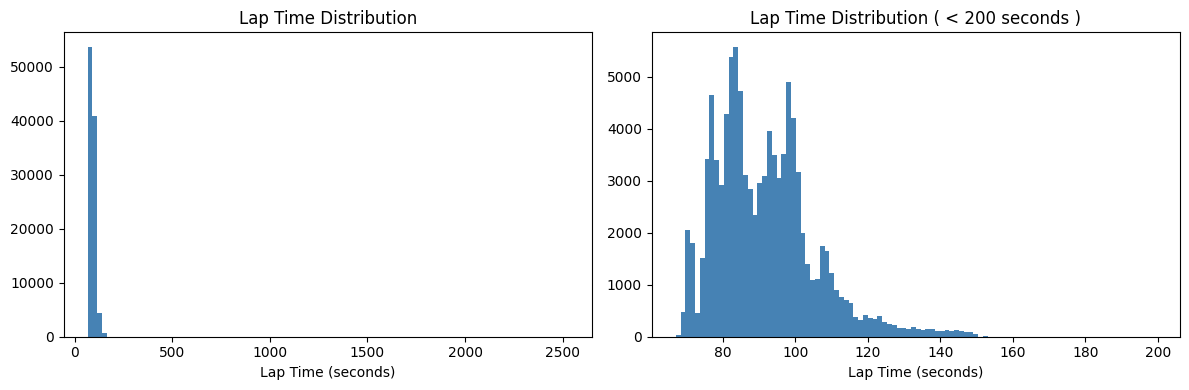

Laps > 200s: 30
Laps > 150s: 99
Laps > 120s: 4,120


In [6]:
import matplotlib.pyplot as plt 

lap_sec = df['LapTime'].dt.total_seconds() 
fig , axes = plt.subplots(1,2, figsize=(12,4)) 

axes[0].hist(lap_sec , bins=100 , color = 'steelblue') 
axes[0].set_title("Lap Time Distribution") 
axes[0].set_xlabel("Lap Time (seconds)") 

axes[1].hist(lap_sec[lap_sec<200] , bins=100 , color = 'steelblue') 
axes[1].set_title("Lap Time Distribution ( < 200 seconds )")
axes[1].set_xlabel("Lap Time (seconds)")

plt.tight_layout() 
plt.show() 

print(f"Laps > 200s: {(lap_sec > 200).sum():,}")
print(f"Laps > 150s: {(lap_sec > 150).sum():,}")
print(f"Laps > 120s: {(lap_sec > 120).sum():,}")

In [8]:
df['LapTimeSec'] = df['LapTime'].dt.total_seconds() 
race_median = df.groupby(['Year', 'RoundNumber'])['LapTimeSec'].transform('median')
df = df[df['LapTimeSec'] <= race_median + 30] 

print(f"After LapTime cleaning: {len(df):,}")

After LapTime cleaning: 96,308


In [9]:
print("Before:", len(df))

df = df[df['TyreLife'] <= 50]

print("After: ", len(df))
print("Removed:", 96308 - len(df))

Before: 96308
After:  94777
Removed: 1531


In [11]:
key_cols = ['LapTime', 'LapTimeSec', 'Compound', 
            'TyreLife', 'TrackTemp', 'AirTemp',
            'Humidity', 'WindSpeed', 'Rainfall',
            'Driver', 'Year', 'RoundNumber', 'LapNumber']

print(df[key_cols].isnull().sum())

LapTime        0
LapTimeSec     0
Compound       0
TyreLife       0
TrackTemp      0
AirTemp        0
Humidity       0
WindSpeed      0
Rainfall       0
Driver         0
Year           0
RoundNumber    0
LapNumber      0
dtype: int64


In [12]:
q1 = df['LapTimeSec'].quantile(0.25)
q3 = df['LapTimeSec'].quantile(0.75)
iqr = q3 - q1   

lower = q1 - 1.5 * iqr 
upper = q3 + 1.5 * iqr 

print(f"Q1     : {q1:.1f}s")
print(f"Q3     : {q3:.1f}s")
print(f"IQR    : {iqr:.1f}s")
print(f"Lower  : {lower:.1f}s")
print(f"Upper  : {upper:.1f}s")
print() 

print(f"Threshold : median + 30s = {df['LapTimeSec'].median() + 30:.1f}s") 
print() 

print(f"Outliers with IQR  : {((df['LapTimeSec'] < lower) | (df['LapTimeSec'] > upper)).sum():,}")
print(f"Outliers we remove: {101297 - len(df):,}") 


Q1     : 81.5s
Q3     : 98.4s
IQR    : 17.0s
Lower  : 56.0s
Upper  : 123.9s

Threshold : median + 30s = 119.2s

Outliers with IQR  : 744
Outliers we remove: 6,520


In [13]:
df.to_parquet(OUTPUT_DIR / "f1_laps_silver.parquet", 
            index=False, compression='snappy')

print(f"Silver saved: {len(df):,} rows")

Silver saved: 94,777 rows
